In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from pandas.io.formats.style import Styler
from statsmodels.stats.outliers_influence import variance_inflation_factor

MECHANISMS = ["m0", "m1", "m2", "m3"]
COMPONENTS = ["ifeval/prompt_accuracy", "entity_fidelity/correct", "truthfulqa/mc1"]
LABELS = {
  "ifeval/prompt_accuracy": "ifeval",
  "entity_fidelity/correct": "fidelity",
  "truthfulqa/mc1": "mc1",
  "truthfulqa/margin": "margin",
  "entity_leakage/entity_leak_rate": "leakage",
}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 200)

In [2]:
ev = pd.read_csv("results/evaluate.csv")
train = pd.read_csv("results/train.csv")
corpus_s = pd.read_csv("results/distortion.csv")

grid = ev[ev.mechanism.isin(["m1", "m2", "m3"])]
print(f"{len(ev)} evaluations, {len(train)} training runs")
ev.groupby(["corpus", "mechanism"]).size().unstack(fill_value=0)

237 evaluations, 273 training runs


mechanism,m0,m1,m2,m3
corpus,,,,
alpaca,9,36,36,36
nemotron,9,36,36,36


## Coverage and sanity

In [3]:
placebo = ev[(ev.mechanism == "m0") | ((ev.mechanism == "m2") & (ev.level == 12))]
placebo.pivot_table(index=["corpus", "model"], columns="mechanism", values=COMPONENTS).round(4)

entity_fidelity/correct         ifeval/prompt_accuracy         truthfulqa/mc1        
mechanism                                           m0      m2                     m0      m2             m0      m2
corpus   model                                                                                                      
alpaca   Falcon3-1B-Instruct                    0.5607  0.5426                 0.2717  0.2711         0.2228  0.2317
         Llama-3.2-1B-Instruct                  0.6784  0.6341                 0.3124  0.3105         0.2436  0.2477
         Qwen3-1.7B                             0.5915  0.4547                 0.4307  0.4104         0.2783  0.2725
nemotron Falcon3-1B-Instruct                    0.9638  0.9647                 0.2169  0.2286         0.2391  0.2411
         Llama-3.2-1B-Instruct                  0.9810  0.9819                 0.3173  0.3241         0.2317  0.2289
         Qwen3-1.7B                             0.9792  0.9792                 0.2575  0.2680         0.2138  0.2199

In [4]:
spread = (
  ev[ev.mechanism.isin(MECHANISMS)]
  .groupby(["corpus", "model", "mechanism", "level"])[COMPONENTS]
  .agg(lambda v: v.max() - v.min())
)
spread.groupby(level=["corpus", "mechanism"]).mean().round(4)

ifeval/prompt_accuracy  entity_fidelity/correct  truthfulqa/mc1
corpus   mechanism                                                                 
alpaca   m0                         0.0246                   0.1748          0.0208
         m1                         0.0294                   0.1784          0.0136
         m2                         0.0245                   0.1458          0.0155
         m3                         0.0368                   0.2344          0.0126
nemotron m0                         0.0351                   0.0100          0.0188
         m1                         0.0331                   0.0340          0.0186
         m2                         0.0283                   0.0784          0.0170
         m3                         0.0456                   0.0611          0.0251

In [5]:
(
  ev[ev.mechanism.isin(["base", "m0"])]
  .groupby(["model", "mechanism"])[COMPONENTS + ["entity_leakage/entity_leak_rate"]]
  .mean()
  .round(4)
)

ifeval/prompt_accuracy  entity_fidelity/correct  truthfulqa/mc1  entity_leakage/entity_leak_rate
model                 mechanism                                                                                                  
Falcon3-1B-Instruct   base                       0.4824                   0.2038          0.3084                           0.0032
                      m0                         0.2443                   0.7622          0.2309                           0.0027
Llama-3.2-1B-Instruct base                       0.5009                   0.0000          0.3011                           0.0032
                      m0                         0.3148                   0.8297          0.2377                           0.0054
Qwen3-1.7B            base                       0.6617                   0.0000          0.3317                           0.0113
                      m0                         0.3441                   0.7853          0.2460                           0.0054

## Response across levels

In [6]:
levels = (
  grid.melt(
    id_vars=["corpus", "mechanism", "d"],
    value_vars=COMPONENTS + ["truthfulqa/margin", "entity_leakage/entity_leak_rate"],
    var_name="metric",
    value_name="value",
  )
  .assign(metric=lambda f: f.metric.map(LABELS))
  .pivot_table(index=["metric", "corpus", "mechanism"], columns="d", values="value", aggfunc="mean")
)
levels.round(4)

d                               1.0     2.0     3.0     4.0
metric   corpus   mechanism                                
fidelity alpaca   m1         0.2563  0.4547  0.4565  0.5242
                  m2         0.3357  0.3373  0.5103  0.5438
                  m3         0.4312  0.4378  0.4460  0.4650
         nemotron m1         0.8511  0.9287  0.9598  0.9686
                  m2         0.7053  0.7005  0.9505  0.9752
                  m3         0.8964  0.9188  0.9269  0.9381
ifeval   alpaca   m1         0.1452  0.1994  0.2288  0.2769
                  m2         0.1887  0.1805  0.3185  0.3307
                  m3         0.3124  0.3192  0.3194  0.3204
         nemotron m1         0.1267  0.1409  0.1676  0.1820
                  m2         0.1826  0.1820  0.2294  0.2736
                  m3         0.2641  0.2510  0.2541  0.2549
leakage  alpaca   m1         0.0000  0.0007  0.0020  0.0029
                  m2         0.0000  0.0000  0.0030  0.0036
                  m3         0.0027  0.0027  0.0034  0.0029
         nemotron m1         0.0014  0.0029  0.0038  0.0038
                  m2         0.0013  0.0007  0.0057  0.0061
                  m3         0.0014  0.0020  0.0020  0.0029
margin   alpaca   m1        -0.7734 -0.7671 -0.8114 -0.8527
                  m2        -0.5425 -0.5399 -0.8151 -0.9086
                  m3        -0.8356 -0.8409 -0.8444 -0.8483
         nemotron m1        -0.7044 -0.7240 -0.7498 -0.7882
                  m2        -0.6048 -0.6109 -0.7789 -0.8984
                  m3        -0.8595 -0.8695 -0.8760 -0.8802
mc1      alpaca   m1         0.2179  0.2277  0.2282  0.2388
                  m2         0.2712  0.2606  0.2433  0.2506
                  m3         0.2372  0.2364  0.2358  0.2380
         nemotron m1         0.2207  0.2218  0.2292  0.2312
                  m2         0.2513  0.2472  0.2225  0.2300
                  m3         0.2304  0.2294  0.2293  0.2279

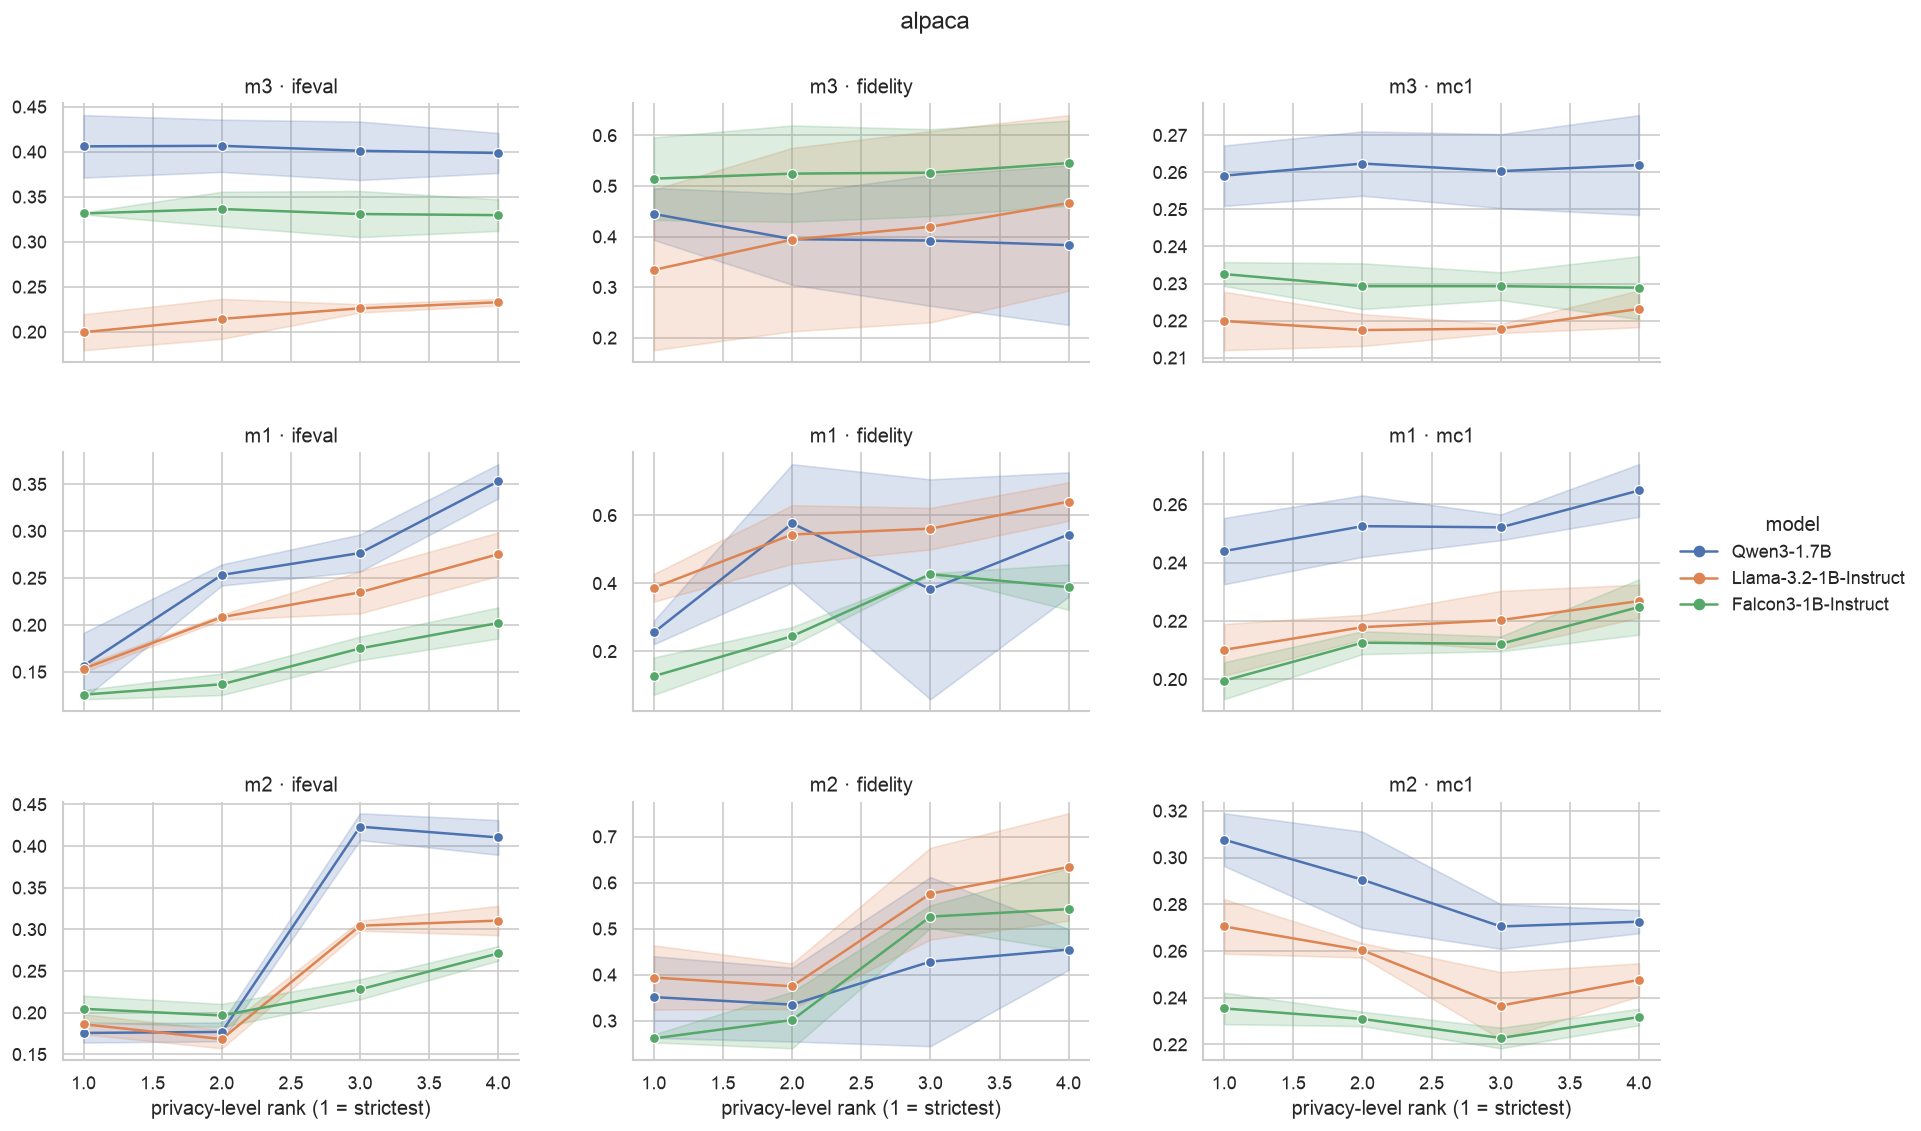

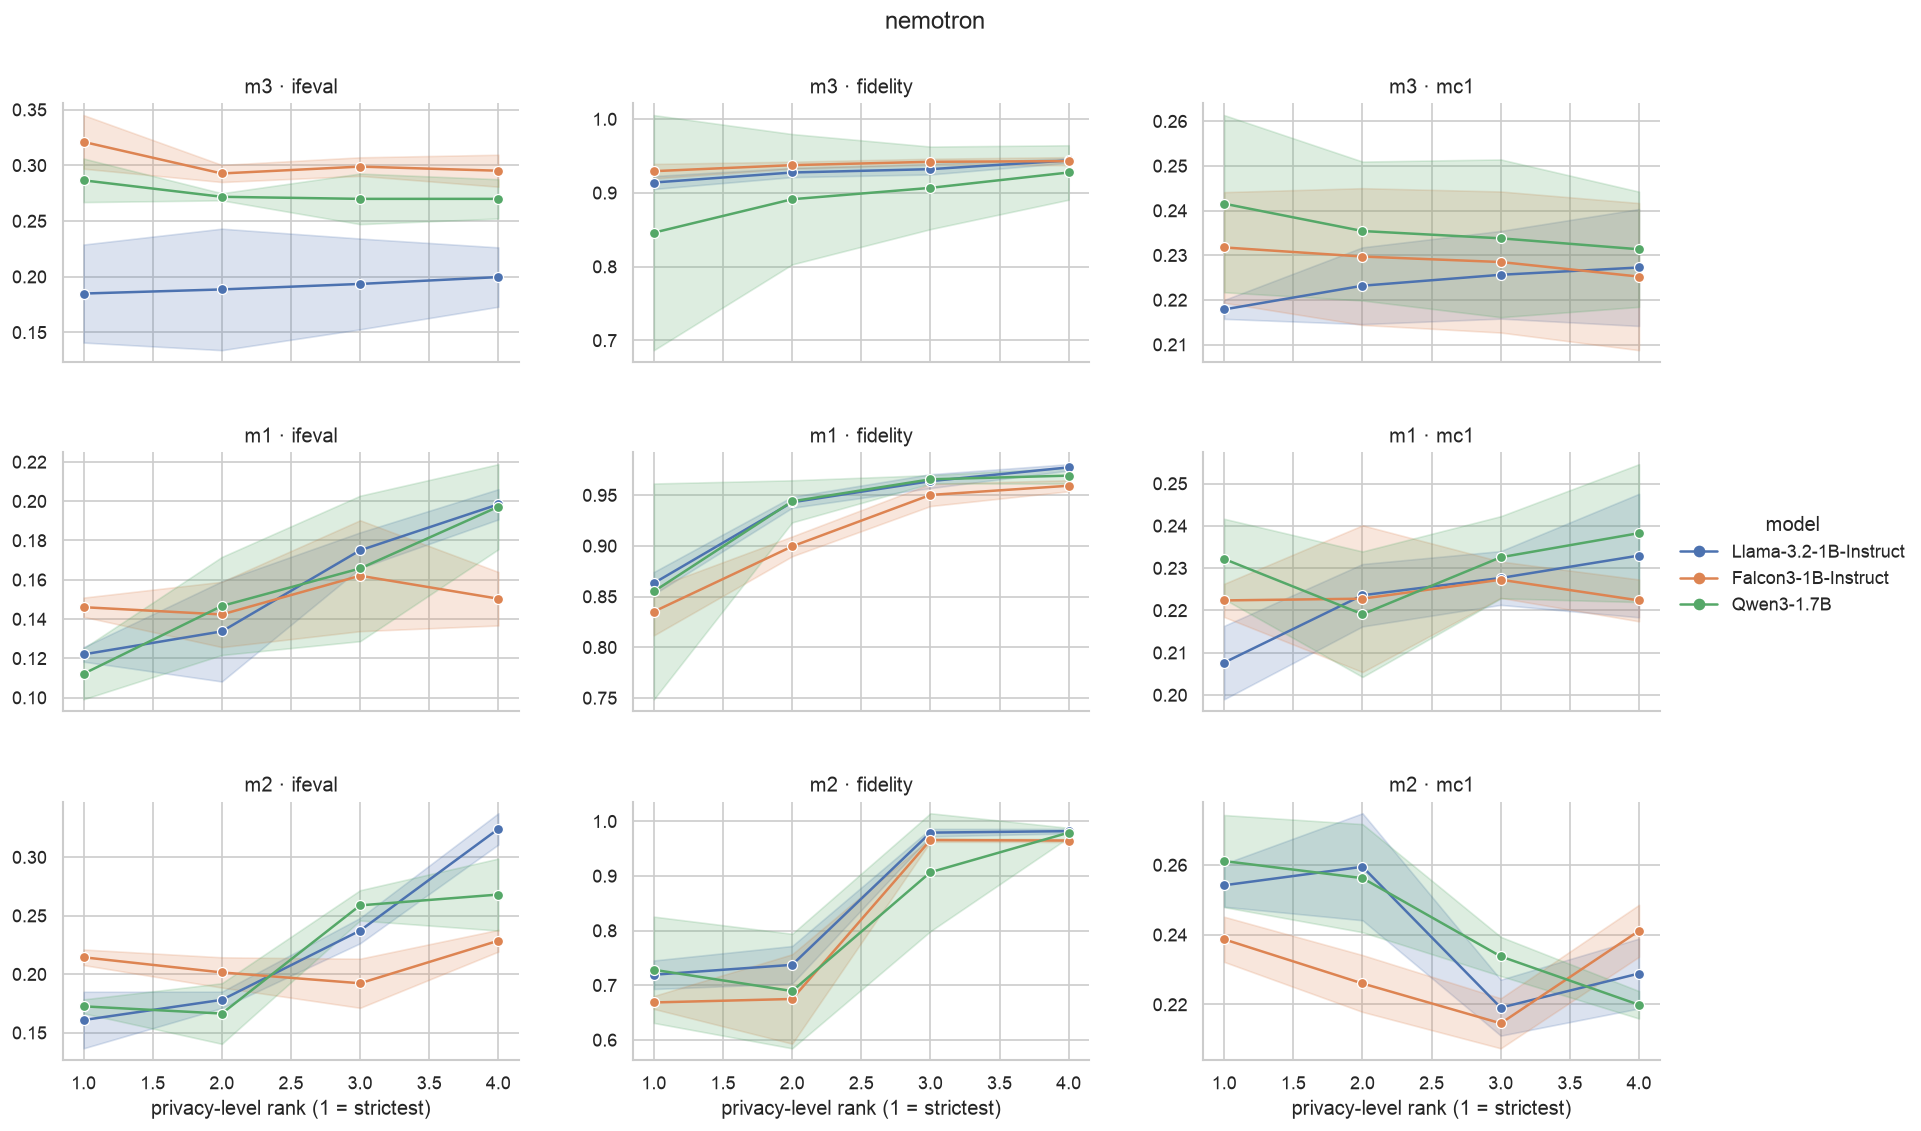

In [7]:
long = grid.melt(
  id_vars=["corpus", "model", "mechanism", "d"], value_vars=COMPONENTS, var_name="metric", value_name="value"
).assign(metric=lambda f: f.metric.map(LABELS))
for corpus in sorted(long.corpus.dropna().unique()):
  g = sns.relplot(
    data=long[long.corpus == corpus],
    x="d",
    y="value",
    hue="model",
    col="metric",
    row="mechanism",
    kind="line",
    marker="o",
    errorbar="sd",
    facet_kws={"sharey": False},
    height=3.2,
    aspect=1.5,
  )
  g.set_titles("{row_name} · {col_name}")
  g.set_axis_labels("privacy-level rank (1 = strictest)", "")
  g.figure.subplots_adjust(top=0.9, hspace=0.35, wspace=0.25)
  g.figure.suptitle(corpus)
  plt.show()

## The dissociation

In [8]:
summary = (
  ev[ev.mechanism.isin(MECHANISMS)]
  .groupby(["corpus", "mechanism"])[
    ["entity_fidelity/correct", "ifeval/prompt_accuracy", "truthfulqa/margin", "entity_leakage/entity_leak_rate"]
  ]
  .mean()
)
delta = summary.copy()
for corpus in delta.index.get_level_values(0).unique():
  delta.loc[corpus] = (delta.loc[corpus] - delta.loc[(corpus, "m0")]).to_numpy()
delta.round(4)

entity_fidelity/correct  ifeval/prompt_accuracy  truthfulqa/margin  entity_leakage/entity_leak_rate
corpus   mechanism                                                                                                     
alpaca   m0                          0.0000                  0.0000             0.0000                           0.0000
         m1                         -0.1873                 -0.1257             0.1094                          -0.0022
         m2                         -0.1784                 -0.0836             0.2090                          -0.0019
         m3                         -0.1652                 -0.0204             0.0682                          -0.0007
nemotron m0                          0.0000                  0.0000             0.0000                           0.0000
         m1                         -0.0476                 -0.1096             0.1529                          -0.0024
         m2                         -0.1418                 -0.0470             0.1713                          -0.0019
         m3                         -0.0546                 -0.0079             0.0232                          -0.0033

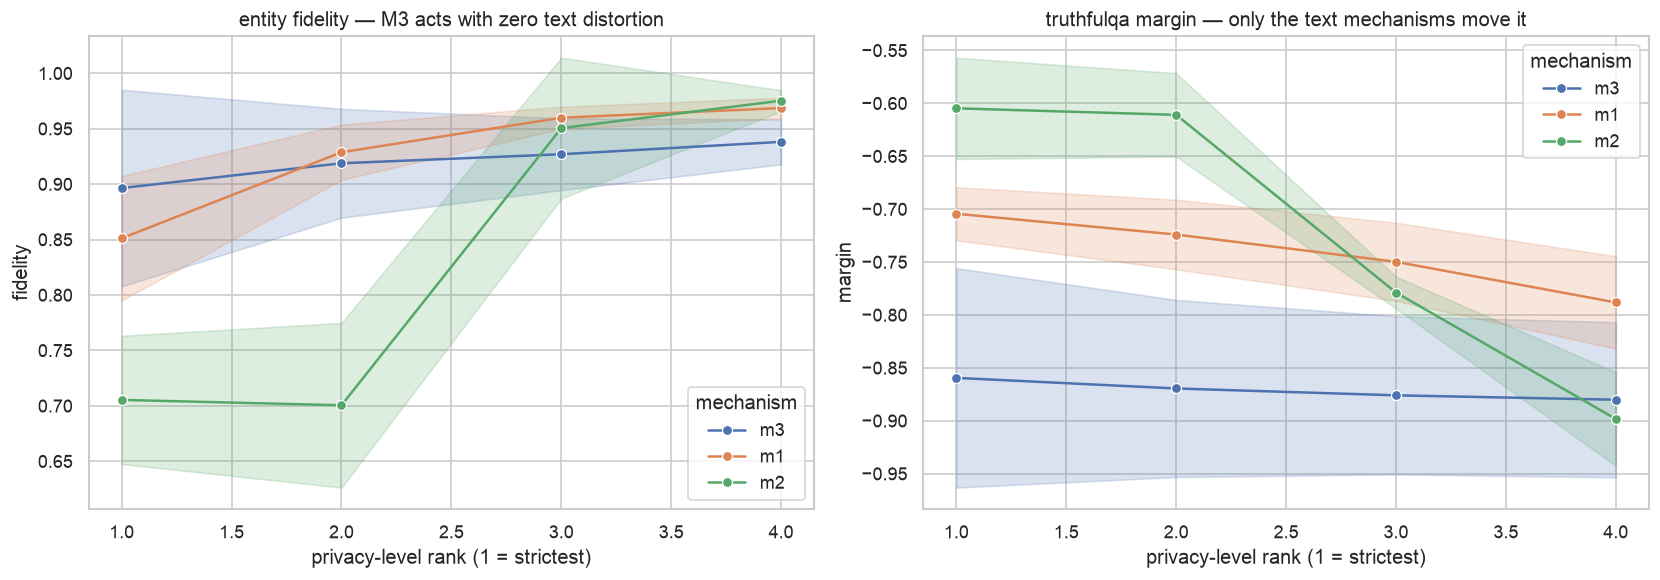

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, title in zip(
  axes,
  ["entity_fidelity/correct", "truthfulqa/margin"],
  ["entity fidelity — M3 acts with zero text distortion", "truthfulqa margin — only the text mechanisms move it"],
):
  sns.lineplot(data=grid[grid.corpus == "nemotron"], x="d", y=metric, hue="mechanism", marker="o", errorbar="sd", ax=ax)
  ax.set_title(title)
  ax.set_xlabel("privacy-level rank (1 = strictest)")
  ax.set_ylabel(LABELS[metric])
plt.tight_layout()
plt.show()

## Identification of `c`

In [10]:
arms = (
  grid.groupby(["corpus", "mechanism", "d"])
  .agg(
    S_corpus=("S_corpus", "mean"), S_gen_side=("S_gen_side", "mean"), S_gen_sd=("S_gen_side", "std"), n=("id", "size")
  )
  .reset_index()
)
arms.round(4)

,corpus,mechanism,d,S_corpus,S_gen_side,S_gen_sd,n
0,alpaca,m1,1.0,0.3223,0.2451,0.0576,9
1,alpaca,m1,2.0,0.2125,0.1816,0.0251,9
2,alpaca,m1,3.0,0.1211,0.1643,0.0116,9
3,alpaca,m1,4.0,0.0466,0.1499,0.0074,9
4,alpaca,m2,1.0,0.5575,0.4452,0.0088,9
5,alpaca,m2,2.0,0.5554,0.4496,0.0060,9
6,alpaca,m2,3.0,0.1012,0.1462,0.0094,9
7,alpaca,m2,4.0,0.0000,0.0967,0.0208,9
8,alpaca,m3,1.0,0.0000,0.1724,0.0237,9
9,alpaca,m3,2.0,0.0000,0.1665,0.0176,9


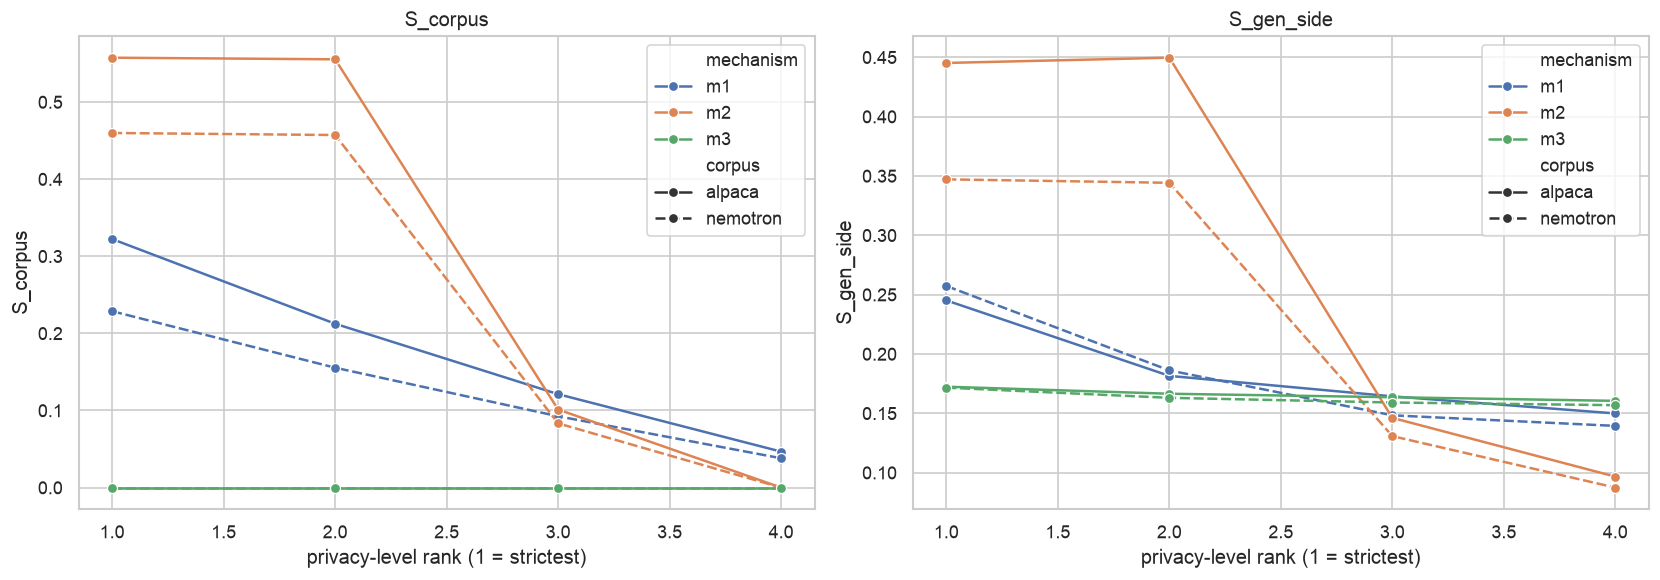

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, column in zip(axes, ["S_corpus", "S_gen_side"]):
  sns.lineplot(data=arms, x="d", y=column, hue="mechanism", style="corpus", marker="o", ax=ax)
  ax.set_title(column)
  ax.set_xlabel("privacy-level rank (1 = strictest)")
plt.tight_layout()
plt.show()

In [12]:
rows = []
for column in ["S_corpus", "S_gen_side"]:
  for mechanism in ["m1", "m2", "m3"]:
    sub = grid[(grid.mechanism == mechanism) & grid[column].notna() & grid.d.notna()]
    if len(sub) < 4:
      rows.append({"S": column, "mechanism": mechanism, "n": len(sub)})
      continue
    design = np.vstack([np.ones(len(sub)), sub.d.to_numpy(float)]).T
    target = sub[column].to_numpy(float)
    residual = target - design @ np.linalg.lstsq(design, target)[0]
    rms, span = float(np.sqrt((residual**2).mean())), float(np.ptp(target))
    rows.append(
      {
        "S": column,
        "mechanism": mechanism,
        "n": len(sub),
        "rms": rms,
        "range": span,
        "share": rms / span if span else np.nan,
        "constant_at": target[0] if span == 0 else np.nan,
      }
    )
pd.DataFrame(rows).round(4)

,S,mechanism,n,rms,range,share,constant_at
0,S_corpus,m1,72,0.0292,0.2843,0.1027,NaN
1,S_corpus,m2,72,0.0919,0.5575,0.1649,NaN
2,S_corpus,m3,72,0.0000,0.0000,NaN,0.0
3,S_gen_side,m1,72,0.0300,0.1941,0.1546,NaN
4,S_gen_side,m2,72,0.0670,0.4060,0.1649,NaN
5,S_gen_side,m3,72,0.0146,0.0712,0.2043,NaN


## Fit

In [13]:
def fit(frame: pd.DataFrame, s_column: str) -> Styler:
  data = frame.dropna(subset=["Y", "d", s_column]).copy()
  data["d_z"] = (data.d - data.d.mean()) / data.d.std()
  data["S_z"] = (data[s_column] - data[s_column].mean()) / data[s_column].std()
  model = smf.mixedlm("Y ~ C(mechanism) + C(mechanism):d_z + S_z", data, groups=data["model"]).fit()
  design = data[["d_z", "S_z"]].assign(const=1.0)
  vif = {name: variance_inflation_factor(design.to_numpy(), i) for i, name in enumerate(design.columns)}
  table = pd.DataFrame({"coef": model.params, "se": model.bse, "p": model.pvalues})
  table["vif"] = [vif.get(name, np.nan) for name in table.index]
  caption = f"S = {s_column} · n = {len(data)} · mechanisms = {', '.join(sorted(data.mechanism.unique()))}"
  return table.round(4).style.set_caption(caption)

In [14]:
fit(grid, "S_corpus")

,coef,se,p,vif
Intercept,0.296500,0.148200,0.045400,nan
C(mechanism)[T.m2],-0.784900,0.113100,0.000000,nan
C(mechanism)[T.m3],-0.104600,0.125000,0.402900,nan
C(mechanism)[m1]:d_z,-0.151500,0.079600,0.057000,nan
C(mechanism)[m2]:d_z,0.311900,0.145600,0.032100,nan
C(mechanism)[m3]:d_z,-0.028100,0.059100,0.635000,nan
S_z,0.517800,0.113300,0.000000,1.429700
Group Var,0.220800,0.235800,0.349100,nan


In [15]:
fit(grid, "S_gen_side")

,coef,se,p,vif
Intercept,0.399100,0.141600,0.004800,nan
C(mechanism)[T.m2],-0.755000,0.098900,0.000000,nan
C(mechanism)[T.m3],-0.442400,0.082900,0.000000,nan
C(mechanism)[m1]:d_z,-0.222400,0.065300,0.000700,nan
C(mechanism)[m2]:d_z,0.285400,0.117600,0.015200,nan
C(mechanism)[m3]:d_z,-0.006500,0.057900,0.911100,nan
S_z,0.436300,0.076800,0.000000,1.541600
Group Var,0.207500,0.222400,0.350800,nan
